# Import Libraries

In [ ]:
# Import Libraries

# Standard Libraries
import itertools
import os
import warnings
import zipfile

# Third-Party Libraries
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# TensorFlow and Keras Components
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Sequential
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import RandomFlip, RandomRotation, GlobalAveragePooling2D, Dense, Dropout, Rescaling
from tensorflow.keras.optimizers import Adam

warnings.filterwarnings('ignore')

# Load Dataset

In [ ]:
# Define dataset path
dataset_path = "/content/food_dataset.zip"  # REMINDER: UPDATE THIS PATH TO UR LOCAL PATH

print("Food11 Dataset Path:", dataset_path)

Food11 Dataset Path: /content/food_dataset.zip


In [ ]:
# Global Setup (Seeds and Parameters)
np.random.seed(42)
tf.random.set_seed(42)

# Image Dimensions and Batching
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

# Training Schedule
EPOCHS_PHASE1=15
EPOCHS_PHASE2=10
FINE_TUNE_START_LAYER_INDEX = -4

In [ ]:
# Data Loading
def load_food_dataset(data_path, img_height, img_width, batch_size):
    """
    Handles dataset file extraction and loads image data from
    'training', 'validation', and 'evaluation' subdirectories using
    tf.keras.utils.image_dataset_from_directory.
    """

    if os.path.isfile(data_path) and data_path.endswith('.zip') and zipfile.is_zipfile(data_path):
        extract_path = '/content/food_dataset'  # Temporary extraction directory
        if not os.path.exists(extract_path):
            os.makedirs(extract_path)
        with zipfile.ZipFile(data_path, 'r') as zip_ref:
            zip_ref.extractall(extract_path) # Extract zip contents
        data_path = extract_path

    data_root_dir = os.path.join(data_path)

    # Basic directory checks
    if not os.path.exists(data_root_dir):
      print(f"Training directory not found at {data_root_dir}")
      if os.path.isdir(data_path):
          print("Available directories:", os.listdir(data_path))
      else:
          print(f"{data_path} is not a directory. Please check the path.")

    train_dir = os.path.join(data_root_dir, 'training')
    val_dir = os.path.join(data_root_dir, 'validation')
    test_dir = os.path.join(data_root_dir, 'evaluation')

    def load_ds(path, subset_name, shuffle):
        """Helper to load one dataset subset (train, val, or test)."""
        print(f"Loading {subset_name} data from {path}")
        ds = tf.keras.utils.image_dataset_from_directory(
            path,
            labels='inferred',
            label_mode='categorical', # Output: one-hot encoded labels
            image_size=(img_height, img_width),
            batch_size=batch_size,
            shuffle=shuffle
        )
        return ds

    # Load the three dataset splits
    train_ds = load_ds(train_dir, 'Training', shuffle=True)
    val_ds = load_ds(val_dir, 'Validation', shuffle=False)
    test_ds = load_ds(test_dir, 'Test/Evaluation', shuffle=False)

    class_names = train_ds.class_names
    NUM_CLASSES = len(class_names)


    def configure_ds(ds):
        """Applies normalization and performance optimizations (NO CACHING)."""
        # Rescale inputs from [0, 255] to [0, 1] for MobileNetV2 input requirements
        normalization_layer = Rescaling(1./255)
        ds = ds.map(lambda x, y: (normalization_layer(x), y))
        # Prefetching allows the data processing pipeline to work concurrently with model training
        ds = ds.prefetch(buffer_size=tf.data.AUTOTUNE)
        return ds

    # Apply configuration to all datasets
    train_ds = configure_ds(train_ds)
    val_ds = configure_ds(val_ds)
    test_ds = configure_ds(test_ds)

    # Reporting
    print("\nData Loading Summary")
    print(f"Found {NUM_CLASSES} food classes: {class_names}")

    # Total images loaded
    total_images = sum(len(files) for _, _, files in os.walk(train_dir))
    print(f"Total Training Images Loaded: {total_images}")
    print(f"Image shape: ({img_height}, {img_width}, 3)")

    return train_ds, val_ds, test_ds, class_names, NUM_CLASSES, train_dir

# Execution
train_ds, val_ds, test_ds, class_names, NUM_CLASSES, train_dir = load_food_dataset(
    dataset_path, IMG_HEIGHT, IMG_WIDTH, BATCH_SIZE)


Loading Training data from /content/food_dataset/training
Found 9866 files belonging to 11 classes.
Loading Validation data from /content/food_dataset/validation
Found 3430 files belonging to 11 classes.
Loading Test/Evaluation data from /content/food_dataset/evaluation
Found 3347 files belonging to 11 classes.

Data Loading Summary
Found 11 food classes: ['Bread', 'Dairy product', 'Dessert', 'Egg', 'Fried food', 'Meat', 'Noodles-Pasta', 'Rice', 'Seafood', 'Soup', 'Vegetable-Fruit']
Total Training Images Loaded: 9866
Image shape: (224, 224, 3)


#Prepare Dataset


Displaying One Sample Image Per Class (11 Classes)


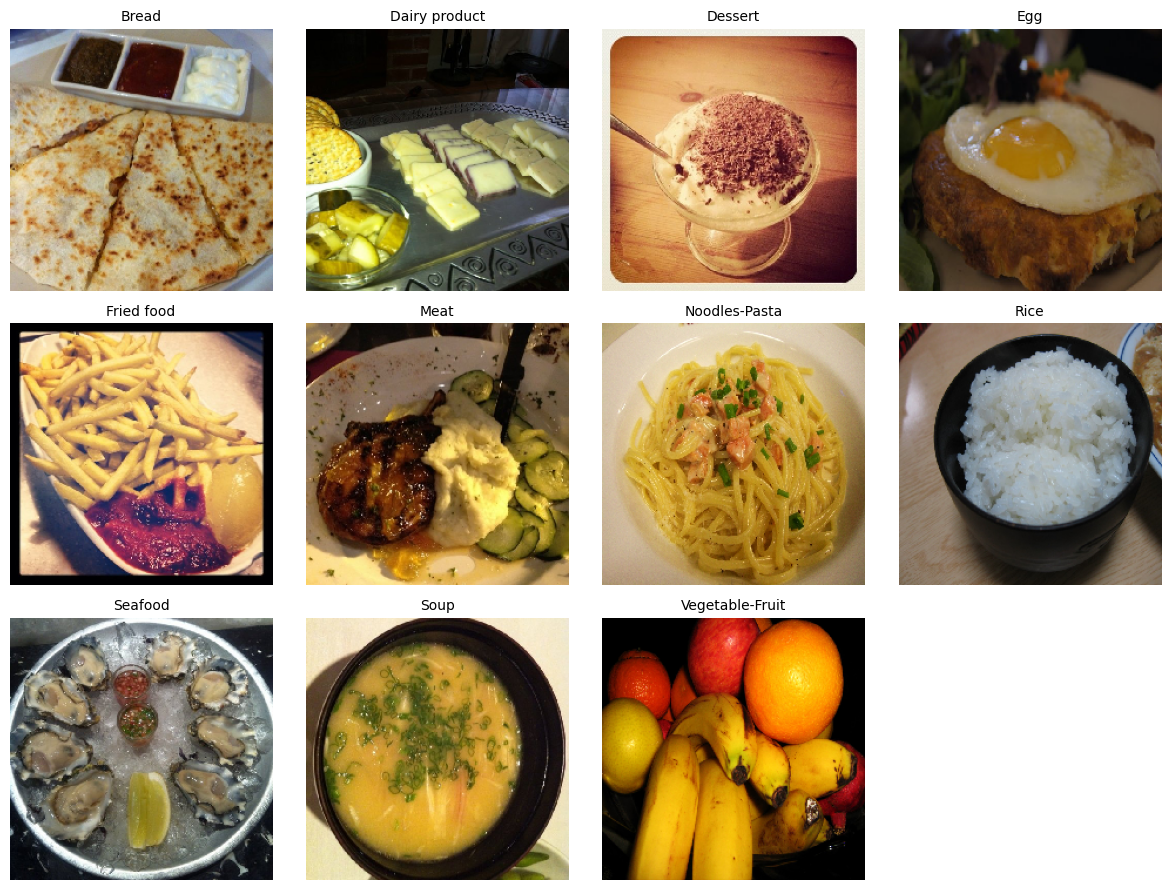

In [ ]:
def display_one_image_per_class(train_dir, class_names, img_height, img_width):
    """
    Reads and plots one sample image from each class directory in the training set
    to visually verify that all classes are present and load correctly.
    """
    print(f"\nDisplaying One Sample Image Per Class ({len(class_names)} Classes)")

    # Determine the best grid size
    num_classes = len(class_names)
    cols = int(np.ceil(np.sqrt(num_classes)))
    rows = int(np.ceil(num_classes / cols))

    plt.figure(figsize=(cols * 3, rows * 3))

    for i, class_name in enumerate(sorted(class_names)):
        class_path = os.path.join(train_dir, class_name)
        if os.path.isdir(class_path):
            file_list = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            if file_list:
                # Get the first image file found in the directory
                img_path = os.path.join(class_path, file_list[0])

                # Load the image using tf.keras.utils.load_img
                img = tf.keras.utils.load_img(img_path, target_size=(img_height, img_width))
                img_array = tf.keras.utils.img_to_array(img)

                # Plotting
                ax = plt.subplot(rows, cols, i + 1)
                # Rescale the image array from [0, 255] for display
                plt.imshow(img_array.astype("uint8"))

                plt.title(f"{class_name}", fontsize=10)
                plt.axis("off")
            else:
                print(f"Warning: No images found in {class_name} directory.")
        else:
            print(f"Warning: Class directory not found for {class_name}.")

    plt.tight_layout()
    plt.show()

display_one_image_per_class(train_dir, class_names, IMG_HEIGHT, IMG_WIDTH)

# Define Performance Matrix

In [ ]:
def plot_history(history):
    """Plots training and validation accuracy and loss over epochs."""

    # Extract metrics from the history object dictionary
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    # Create the range of epoch numbers for the X-axis
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))

    # Plot 1: Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', color='blue')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='red')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')

    # Plot 2: Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', color='blue')
    plt.plot(epochs_range, val_loss, label='Validation Loss', color='red')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.show()

In [ ]:
def plot_confusion_matrix(cm, class_names, title='Confusion Matrix', cmap=plt.cm.Blues):
    """Prints and plots the confusion matrix."""
    plt.figure(figsize=(10, 8))

    # Display the confusion matrix using a color map
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()

    # Set axis ticks and labels
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45, ha='right')
    plt.yticks(tick_marks, class_names)

    # Normalize the matrix for better visualization
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # Add text annotations to the plot
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

In [ ]:
# Extract True Labels
all_true_labels = []
for _, labels in test_ds:
    all_true_labels.append(tf.argmax(labels, axis=1).numpy())
true_labels_int = np.concatenate(all_true_labels, axis=0)

# Define CNN Model: Transfer Learning Model using MobileNetV2

In [ ]:
def setup_training_callbacks(patience):
    """
    Configure callbacks for optimal training: EarlyStopping and Learning Rate Reduction.
    EarlyStopping: Stops training when validation accuracy stops improving for 'patience' number of epochs.
    ReduceLROnPlateau: Reduces the learning rate by half if validation loss plateaus (no improvement after 2 epochs).
    """
    print("\nConfiguring Keras Callbacks")

    # Early stopping to prevent overfitting
    early_stopping = EarlyStopping(
        monitor='val_accuracy', # Metric to monitor
        patience= patience, # Number of epochs with no improvement after which training will be stopped
        restore_best_weights=True, # Restores model weights from the epoch with the best monitored value
        verbose=1,
        mode='max' # Look for maximum val_accuracy
    )

    # Learning rate reduction when training plateaus
    lr_reduction = ReduceLROnPlateau(
        monitor='val_loss',
        patience=2, # Number of epochs with no improvement before reducing LR
        factor=0.5, # Factor by which the learning rate will be reduced
        min_lr=1e-6,
        verbose=1,
        mode='min' # Look for minimum val_loss
    )

    return [early_stopping, lr_reduction]

In [ ]:
def create_food_classification_model(input_shape, num_classes):
    """
    Creates a Transfer Learning model using MobileNetV2 base, initially frozen for Feature Extraction.
    """
    # Load Pre-trained Base Model (MobileNetV2)
    base_model = MobileNetV2(
        weights='imagenet', # Use weights pre-trained on the ImageNet dataset
        include_top=False, # Exclude the final classification layer of MobileNetV2
        input_shape=input_shape
    )

    # Freeze the Base Model Layers (Feature Extraction Strategy)
    base_model.trainable = False

    inputs = keras.Input(shape=input_shape)

    # Data Augmentation layer to introduce randomness and increase the effective dataset size
    data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    ], name='data_augmentation')

    x = data_augmentation(inputs)

    # Pass input through the frozen MobileNetV2 base
    x = base_model(x, training=False)

    # Apply classifier head layers:
    # Global Average Pooling reduces the spatial dimensions to 1, preparing for the dense layers
    x = GlobalAveragePooling2D(name='global_avg_pool')(x)

    # First dense layer with ReLU activation
    x = Dense(1024, activation='relu', name='dense_1024')(x)
    # Dropout layer for regularization to prevent overfitting
    x = Dropout(0.5, name='dropout_1')(x)

    # Second dense layer with ReLU activation
    x = Dense(512, activation='relu', name='dense_512')(x)
    # Dropout layer for regularization
    x = Dropout(0.5, name='dropout_2')(x)

    # Output layer with 'softmax' activation for multi-class probability distribution
    outputs = Dense(num_classes, activation='softmax', name='output_phase1')(x)

    model = Model(inputs, outputs, name='mobilenetv2_TransferLearningModel')

    # Compile the Model
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    print("\nModel Summary")
    model.summary()
    print(f"Food Classification Model compiled successfully for {NUM_CLASSES} classes.")

    return model, base_model

# Model Initialization and Compilation
model, base_model = create_food_classification_model(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3), num_classes=NUM_CLASSES)


Model Summary


Model: "mobilenetv2_TransferLearningModel"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1024 (Dense)              │ (None, 1024)           │     1,311,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_512 (Dense)               │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_phase1 (Dense)           │ (None, 11)             │         5,643 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,100,171 (15.64 MB)

 Trainable params: 1,842,187 (7.03 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Food Classification Model compiled successfully for 11 classes.


In [ ]:
# Training CNN Model
print(f"\nStarting Training")
print(f"Training for {EPOCHS_PHASE1} epochs.")


callbacks = setup_training_callbacks(patience=3)
history_phase1 = model.fit(train_ds,
                    validation_data=val_ds,
                    epochs=EPOCHS_PHASE1,
                    callbacks=callbacks)

# Analyze training completion
final_epoch = len(history_phase1.history['accuracy'])
final_train_acc = history_phase1.history['accuracy'][-1]
final_val_acc = history_phase1.history['val_accuracy'][-1]
train_val_gap = final_train_acc - final_val_acc

print(f"\nTraining completed at epoch {final_epoch}")
if final_epoch < EPOCHS_PHASE1:
    print("Early stopping activated successfully")

print(f"Final train-validation gap: {train_val_gap:.3f} ({train_val_gap*100:.1f}%)")


Starting Training
Training for 15 epochs.

Configuring Keras Callbacks
Epoch 1/15
309/309 ━━━━━━━━━━━━━━━━━━━━ 43s 111ms/step - accuracy: 0.5366 - loss: 1.4784 - val_accuracy: 0.7889 - val_loss: 0.6816 - learning_rate: 0.0010
Epoch 2/15
309/309 ━━━━━━━━━━━━━━━━━━━━ 34s 111ms/step - accuracy: 0.7364 - loss: 0.8063 - val_accuracy: 0.8114 - val_loss: 0.6051 - learning_rate: 0.0010
Epoch 3/15
309/309 ━━━━━━━━━━━━━━━━━━━━ 33s 108ms/step - accuracy: 0.7753 - loss: 0.7110 - val_accuracy: 0.8041 - val_loss: 0.6031 - learning_rate: 0.0010
Epoch 4/15
309/309 ━━━━━━━━━━━━━━━━━━━━ 34s 109ms/step - accuracy: 0.7917 - loss: 0.6567 - val_accuracy: 0.8201 - val_loss: 0.5637 - learning_rate: 0.0010
Epoch 5/15
309/309 ━━━━━━━━━━━━━━━━━━━━ 34s 110ms/step - accuracy: 0.8036 - loss: 0.6111 - val_accuracy: 0.8329 - val_loss: 0.5301 - learning_rate: 0.0010
Epoch 6/15
309/309 ━━━━━━━━━━━━━━━━━━━━ 33s 107ms/step - accuracy: 0.8136 - loss: 0.5752 - val_accuracy: 0.8309 - val_loss: 0.5411 - learning_rate: 0.001

# Performance Evaluation and Metrics: Feature Extraction

In [ ]:
# Generate Predictions (Feature Extraction Phase)
# Predict class probabilities for the test dataset
predictions = model.predict(test_ds, verbose=0)
# Convert probabilities to class indices (the final prediction)
predicted_labels = np.argmax(predictions, axis=1)

In [ ]:
# Metrics (Precision, Recall, F1-score, Accuracy)
print("\nClassification Report (Feature Extraction):")
print(classification_report(true_labels_int, predicted_labels, target_names=class_names, zero_division=0))


Classification Report (Feature Extraction):
                 precision    recall  f1-score   support

          Bread       0.88      0.79      0.83       368
  Dairy product       0.83      0.74      0.78       148
        Dessert       0.82      0.79      0.81       500
            Egg       0.78      0.86      0.82       335
     Fried food       0.81      0.82      0.82       287
           Meat       0.89      0.90      0.89       432
  Noodles-Pasta       0.99      0.96      0.97       147
           Rice       0.90      0.92      0.91        96
        Seafood       0.85      0.90      0.87       303
           Soup       0.95      0.97      0.96       500
Vegetable-Fruit       0.93      0.96      0.95       231

       accuracy                           0.87      3347
      macro avg       0.88      0.87      0.87      3347
   weighted avg       0.87      0.87      0.87      3347




Generating Accuracy and Loss Plots (Feature Extraction)


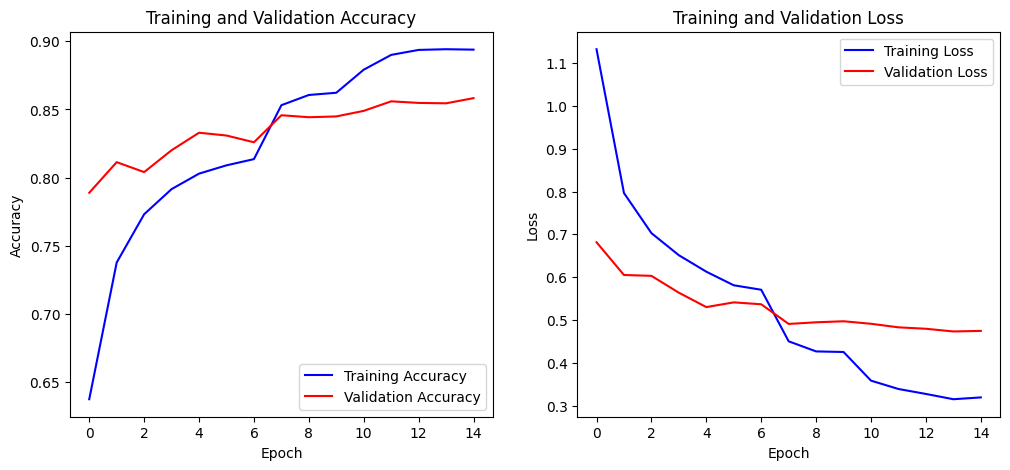

In [ ]:
# Accuracy and Loss Plots
print("\nGenerating Accuracy and Loss Plots (Feature Extraction)")
plot_history(history_phase1)


Generating Confusion Matrix Plot (Feature Extraction)


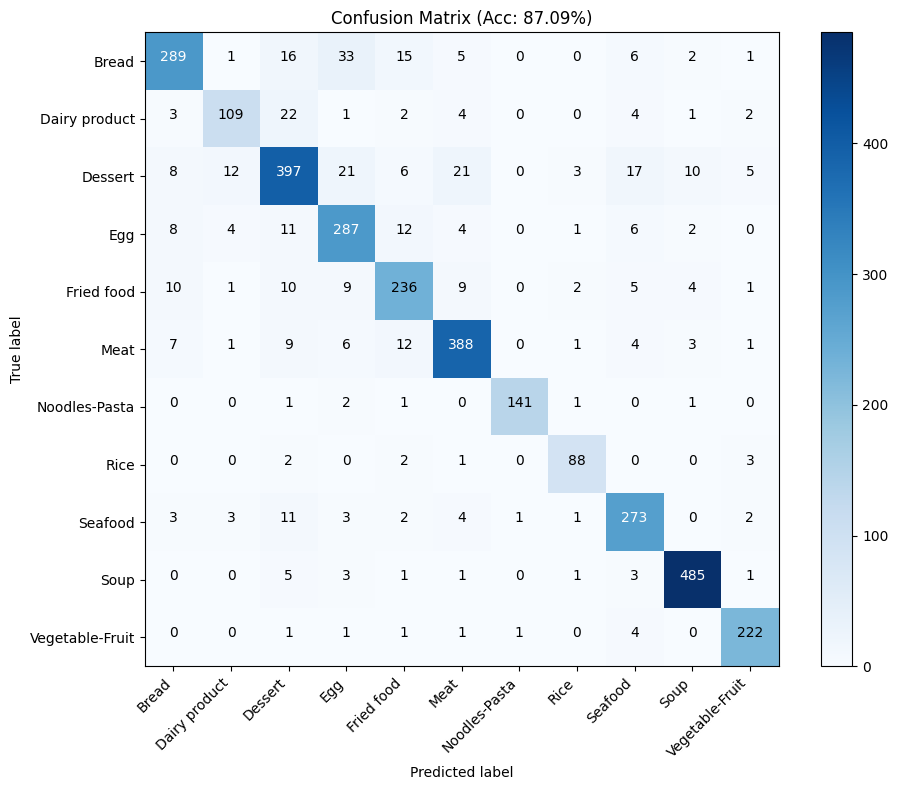

In [ ]:
# Confusion Matrix
cm = confusion_matrix(true_labels_int, predicted_labels)
print("\nGenerating Confusion Matrix Plot (Feature Extraction)")

loss, accuracy = model.evaluate(test_ds, verbose=0)

plot_confusion_matrix(cm, class_names, title=f'Confusion Matrix (Acc: {accuracy*100:.2f}%)')

# Fine-Tune Model

In [ ]:
def create_food_classification_ft_model(model, base_model, start_layer):
    """
    Sets up the model for the Fine-Tuning phase.
    Unfreezes the top layers and recompiles with low learning rate.
    """

    # Set Base Model Trainability to TRUE for Fine-Tuning
    base_model.trainable = True

    # Freeze layers up to the 'start_layer' index
    for i, layer in enumerate(base_model.layers):
        if i < (len(base_model.layers) + start_layer):
            layer.trainable = False
        else:
            layer.trainable = True

    # Compile the Model for Fine-Tuning
    model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
    )

    num_trainable = sum(tf.keras.backend.count_params(w) for w in model.trainable_weights)
    num_frozen = sum(tf.keras.backend.count_params(w) for w in model.non_trainable_weights)

    print(f"\nFine-Tuning Summary")
    print(f"Total Trainable Params: {num_trainable / 1e6:.2f}M")
    print(f"Total Non-Trainable Params: {num_frozen / 1e6:.2f}M")
    print(f"Base model unfrozen from layer {len(base_model.layers) + start_layer} onwards (top {abs(start_layer)} blocks).")

    return model

In [ ]:
# Initialize and Compile Model (Fine-Tuning)
ft_model = create_food_classification_ft_model(
    model, base_model, start_layer=FINE_TUNE_START_LAYER_INDEX)

ft_model.summary(expand_nested=True, show_trainable=True)


Fine-Tuning Summary
Total Trainable Params: 2.25M
Total Non-Trainable Params: 1.85M
Base model unfrozen from layer 150 onwards (top 4 blocks).


Model: "mobilenetv2_TransferLearningModel"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1 (InputLayer)  │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ data_augmentation           │ (None, 224, 224, 3)   │          0 │   -   │
│ (Sequential)                │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│    └ random_flip            │ (None, 224, 224, 3)   │          0 │   -   │
│ (RandomFlip)                │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│    └ random_rotation        │ (None, 224, 224, 3)   │          0 │   -   │
│ (RandomRotation)            │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ mobilenetv2_1.00_224        │ (None, 7, 7, 1280)    │  2,257,984 │   Y   │
│ (Functional)                │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│    └ input_layer            │ (None, 224, 224, 3)   │          0 │   -   │
│ (InputLayer)                │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│    └ Conv1 (Conv2D)         │ (None, 112, 112, 32)  │        864 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│    └ bn_Conv1               │ (None, 112, 112, 32)  │        128 │   N   │
│ (BatchNormalization)        │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│    └ Conv1_relu (ReLU)      │ (None, 112, 112, 32)  │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│    └                        │ (None, 112, 112, 32)  │        288 │   N   │
│ expanded_conv_depthwise     │                       │            │       │
│ (DepthwiseConv2D)           │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│    └                        │ (None, 112, 112, 32)  │        128 │   N   │
│ expanded_conv_depthwise_BN  │                       │            │       │
│ (BatchNormalization)        │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│    └                        │ (None, 112, 112, 32)  │          0 │   -   │
│ expanded_conv_depthwise_re… │                       │            │       │
│ (ReLU)                      │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│    └ expanded_conv_project  │ (None, 112, 112, 16)  │        512 │   N   │
│ (Conv2D)                    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│    └                        │ (None, 112, 112, 16)  │         64 │   N   │
│ expanded_conv_project_BN    │                       │            │       │
│ (BatchNormalization)        │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│    └ block_1_expand         │ (None, 112, 112, 96)  │      1,536 │   N   │
│ (Conv2D)                    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│    └ block_1_expand_BN      │ (None, 112, 112, 96)  │        384 │   N   │
│ (BatchNormalization)        │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼─────

 Total params: 4,100,171 (15.64 MB)

 Trainable params: 2,254,987 (8.60 MB)

 Non-trainable params: 1,845,184 (7.04 MB)

In [ ]:
# Calculate the starting epoch number for fine-tuning
initial_epoch_ft = history_phase1.epoch[-1] + 1 if history_phase1.epoch else 0

callbacks = setup_training_callbacks(patience=5) # Reconfigure callbacks with patience=5 epochs for Fine-Tuning

print(f"\nStarting Fine-Tuning Training ({EPOCHS_PHASE2} epochs)")
ft_history = ft_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=initial_epoch_ft + EPOCHS_PHASE2, # Total epochs = epochs already run + new fine-tuning epochs
    callbacks=callbacks
)

# Analyze training completion
final_epoch = len(ft_history.history['accuracy'])
final_train_acc = ft_history.history['accuracy'][-1]
final_val_acc = ft_history.history['val_accuracy'][-1]
train_val_gap = final_train_acc - final_val_acc

print(f"\nTraining completed at epoch {final_epoch}")
if final_epoch < (initial_epoch_ft + EPOCHS_PHASE2):
    print("Early stopping activated successfully")

print(f"Final train-validation gap: {train_val_gap:.3f} ({train_val_gap*100:.1f}%)")


Configuring Keras Callbacks

Starting Fine-Tuning Training (10 epochs)
Epoch 1/25
309/309 ━━━━━━━━━━━━━━━━━━━━ 42s 113ms/step - accuracy: 0.8116 - loss: 0.7564 - val_accuracy: 0.8402 - val_loss: 0.5279 - learning_rate: 1.0000e-05
Epoch 2/25
309/309 ━━━━━━━━━━━━━━━━━━━━ 33s 106ms/step - accuracy: 0.8623 - loss: 0.4734 - val_accuracy: 0.8385 - val_loss: 0.5392 - learning_rate: 1.0000e-05
Epoch 3/25
309/309 ━━━━━━━━━━━━━━━━━━━━ 34s 110ms/step - accuracy: 0.8741 - loss: 0.3799 - val_accuracy: 0.8449 - val_loss: 0.5214 - learning_rate: 1.0000e-05
Epoch 4/25
309/309 ━━━━━━━━━━━━━━━━━━━━ 34s 110ms/step - accuracy: 0.8819 - loss: 0.3744 - val_accuracy: 0.8510 - val_loss: 0.5028 - learning_rate: 1.0000e-05
Epoch 5/25
309/309 ━━━━━━━━━━━━━━━━━━━━ 34s 111ms/step - accuracy: 0.8821 - loss: 0.3633 - val_accuracy: 0.8583 - val_loss: 0.4915 - learning_rate: 1.0000e-05
Epoch 6/25
309/309 ━━━━━━━━━━━━━━━━━━━━ 42s 114ms/step - accuracy: 0.8881 - loss: 0.3347 - val_accuracy: 0.8589 - val_loss: 0.4852 - 

# Performance Evaluation and Metrics: Fine-Tune

In [ ]:
# Generate Predictions (Fine-Tuning)
# Predict class probabilities for the test dataset using the fine-tuned model
predictions = ft_model.predict(test_ds, verbose=0)
# Convert probabilities to class indices
predicted_labels = np.argmax(predictions, axis=1)

In [ ]:
# Metrics (Precision, Recall, F1-score, Accuracy)
print("\nClassification Report (Fine-Tuning):")
print(classification_report(true_labels_int, predicted_labels, target_names=class_names, zero_division=0))


Classification Report (Fine-Tuning):
                 precision    recall  f1-score   support

          Bread       0.82      0.82      0.82       368
  Dairy product       0.90      0.75      0.82       148
        Dessert       0.86      0.78      0.81       500
            Egg       0.81      0.85      0.83       335
     Fried food       0.81      0.84      0.82       287
           Meat       0.85      0.90      0.87       432
  Noodles-Pasta       0.98      0.98      0.98       147
           Rice       0.89      0.97      0.93        96
        Seafood       0.88      0.90      0.89       303
           Soup       0.96      0.96      0.96       500
Vegetable-Fruit       0.93      0.96      0.94       231

       accuracy                           0.87      3347
      macro avg       0.88      0.88      0.88      3347
   weighted avg       0.87      0.87      0.87      3347




Generating Accuracy and Loss Plots (Fine-Tuning)


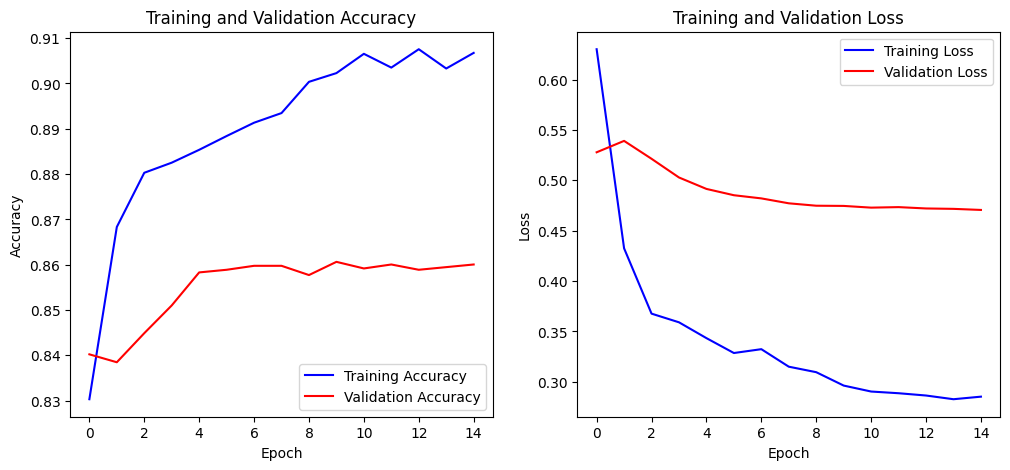

In [ ]:
# Accuracy and Loss Plots
print("\nGenerating Accuracy and Loss Plots (Fine-Tuning)")
plot_history(ft_history)


Generating Confusion Matrix Plot (Fine-Tuning))


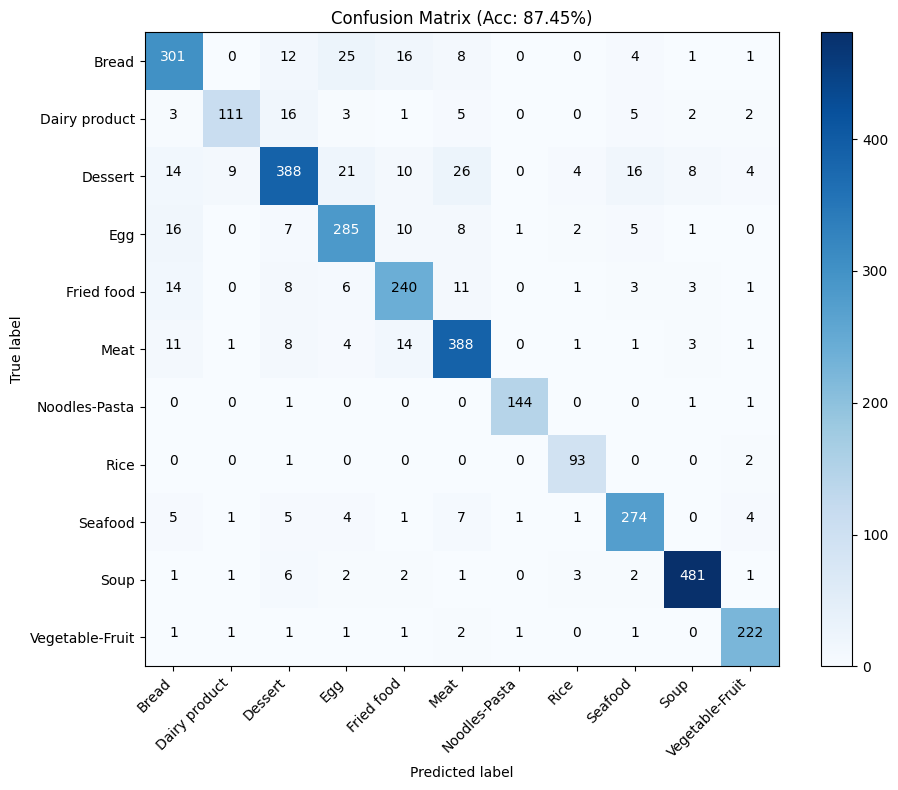

In [ ]:
# Confusion Matrix
cm = confusion_matrix(true_labels_int, predicted_labels)
print("\nGenerating Confusion Matrix Plot (Fine-Tuning))")

loss, accuracy = ft_model.evaluate(test_ds, verbose=0)

plot_confusion_matrix(cm, class_names, title=f'Confusion Matrix (Acc: {accuracy*100:.2f}%)')